# **ME315 Project: Predicting Track Popularity and Genre from Spotify Audio Features**
## *By Max Ringelstein*



## **Initializing:**


*   Imports
*   Google Colab set up
*   Load and clean data
*   Feature engineering



In [21]:
# IMPORTS
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from pathlib import Path
from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler
from sklearn.pipeline import make_pipeline
from sklearn.linear_model import LinearRegression, Ridge, Lasso, LogisticRegression
from sklearn.discriminant_analysis import LinearDiscriminantAnalysis, QuadraticDiscriminantAnalysis
from sklearn.metrics import (
    accuracy_score,
    precision_score,
    recall_score,
    f1_score,
    confusion_matrix,
    ConfusionMatrixDisplay,
    roc_curve,
    roc_auc_score,
    log_loss
)
import warnings
warnings.filterwarnings("ignore")

SEED = 42

In [22]:
# GOOGLE COLAB SETUP
from google.colab import drive
drive.mount('/content/drive')

import os
path = '/content/drive/MyDrive/Colab Notebooks/ME315/Project_ME315'
os.chdir(path)

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [23]:
# LOAD AND CLEAN DATA ---------------
df = pd.read_csv('SpotifyFeatures.csv')

# Some tracks appear under multiple genres --> deduplicate to one row per song
df = (df
      .drop_duplicates(subset='track_id')
      .dropna(subset=['track_name'])
      .reset_index(drop=True))

print(f'Dataset shape: {df.shape}') # Goes from 232725 rows --> 176773 rows
print(f'Columns: {df.columns.tolist()}') # Show column names
df.head() # Preview df

Dataset shape: (176773, 18)
Columns: ['genre', 'artist_name', 'track_name', 'track_id', 'popularity', 'acousticness', 'danceability', 'duration_ms', 'energy', 'instrumentalness', 'key', 'liveness', 'loudness', 'mode', 'speechiness', 'tempo', 'time_signature', 'valence']


,genre,artist_name,track_name,track_id,popularity,acousticness,danceability,duration_ms,energy,instrumentalness,key,liveness,loudness,mode,speechiness,tempo,time_signature,valence
0,Movie,Henri Salvador,C'est beau de faire un Show,0BRjO6ga9RKCKjfDqeFgWV,0,0.611,0.389,99373,0.910,0.000,C#,0.3460,-1.828,Major,0.0525,166.969,4/4,0.814
1,Movie,Martin & les fées,Perdu d'avance (par Gad Elmaleh),0BjC1NfoEOOusryehmNudP,1,0.246,0.590,137373,0.737,0.000,F#,0.1510,-5.559,Minor,0.0868,174.003,4/4,0.816
2,Movie,Joseph Williams,Don't Let Me Be Lonely Tonight,0CoSDzoNIKCRs124s9uTVy,3,0.952,0.663,170267,0.131,0.000,C,0.1030,-13.879,Minor,0.0362,99.488,5/4,0.368
3,Movie,Henri Salvador,Dis-moi Monsieur Gordon Cooper,0Gc6TVm52BwZD07Ki6tIvf,0,0.703,0.240,152427,0.326,0.000,C#,0.0985,-12.178,Major,0.0395,171.758,4/4,0.227
4,Movie,Fabien Nataf,Ouverture,0IuslXpMROHdEPvSl1fTQK,4,0.950,0.331,82625,0.225,0.123,F,0.2020,-21.150,Major,0.0456,140.576,4/4,0.390


In [24]:
# Feature engineering
df['mode_enc']     = (df['mode'] == 'Major').astype(int)          # Major=1, Minor=0
df['is_4_4']       = (df['time_signature'] == '4/4').astype(int)  # 4/4=1, else 0
df['duration_min'] = df['duration_ms'] / 60000                    # ms → minutes

# Final 12-feature set
features = ['acousticness', 'danceability', 'energy', 'instrumentalness',
            'liveness', 'loudness', 'speechiness', 'tempo', 'valence',
            'duration_min', 'mode_enc', 'is_4_4']

# Continuous vs binary split (for plotting / outlier analysis)
continuous = ['acousticness', 'danceability', 'energy', 'instrumentalness',
              'liveness', 'loudness', 'speechiness', 'tempo', 'valence',
              'duration_min']
binary = ['mode_enc', 'is_4_4']

print(f'Engineered features created. Feature count: {len(features)}')
print(df[features].dtypes)

Engineered features created. Feature count: 12
acousticness        float64
danceability        float64
energy              float64
instrumentalness    float64
liveness            float64
loudness            float64
speechiness         float64
tempo               float64
valence             float64
duration_min        float64
mode_enc              int64
is_4_4                int64
dtype: object


# **Exploratory Data Analysis (EDA)**


*   2.1 Target distributions
    * Task 1 target: popularity (full dataset).
    * Task 2 target: genre (6-class subset).
*   2.2 Feature distributions
    * Continous features
    * Binary features
    * Outlier summary
*   2.3 Correlation structure
    * (a) Feature–feature heatmap (continuous features only)
    * (b) Feature–popularity correlations (Task 1 target only)
    * Numeric summaries
*   *Pivot motivation: why `mode` was rejected as the classification target*

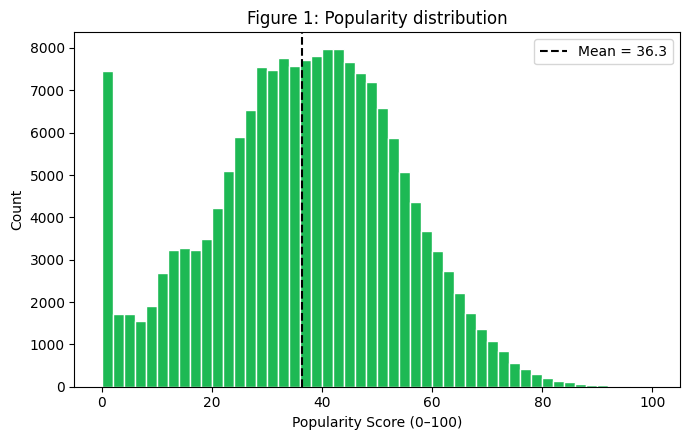

POPULARITY (Task 1 target)
count    176773.00
mean         36.27
std          17.39
min           0.00
25%          25.00
50%          37.00
75%          49.00
max         100.00

% of tracks with popularity == 0: 3.49%


In [25]:
# EDA 2.1: Target distributions
# Task 1 target: popularity (full dataset). Task 2 target: genre (6-class subset).
fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(df['popularity'], bins=50, color='#1DB954', edgecolor='white')
ax.axvline(df['popularity'].mean(), color='black', linestyle='--',
           label=f"Mean = {df['popularity'].mean():.1f}")
ax.set_title('Figure 1: Popularity distribution')
ax.set_xlabel('Popularity Score (0–100)')
ax.set_ylabel('Count')
ax.legend()
plt.tight_layout()
plt.show()

print('POPULARITY (Task 1 target)')
print(df['popularity'].describe().round(2).to_string())
print(f"\n% of tracks with popularity == 0: {(df['popularity'] == 0).mean() * 100:.2f}%")

# Genre class distribution is shown in the Task 2 section (Figure 5 area),
# after the 6-genre subset `gdf` is built, since genre uses a different dataset.

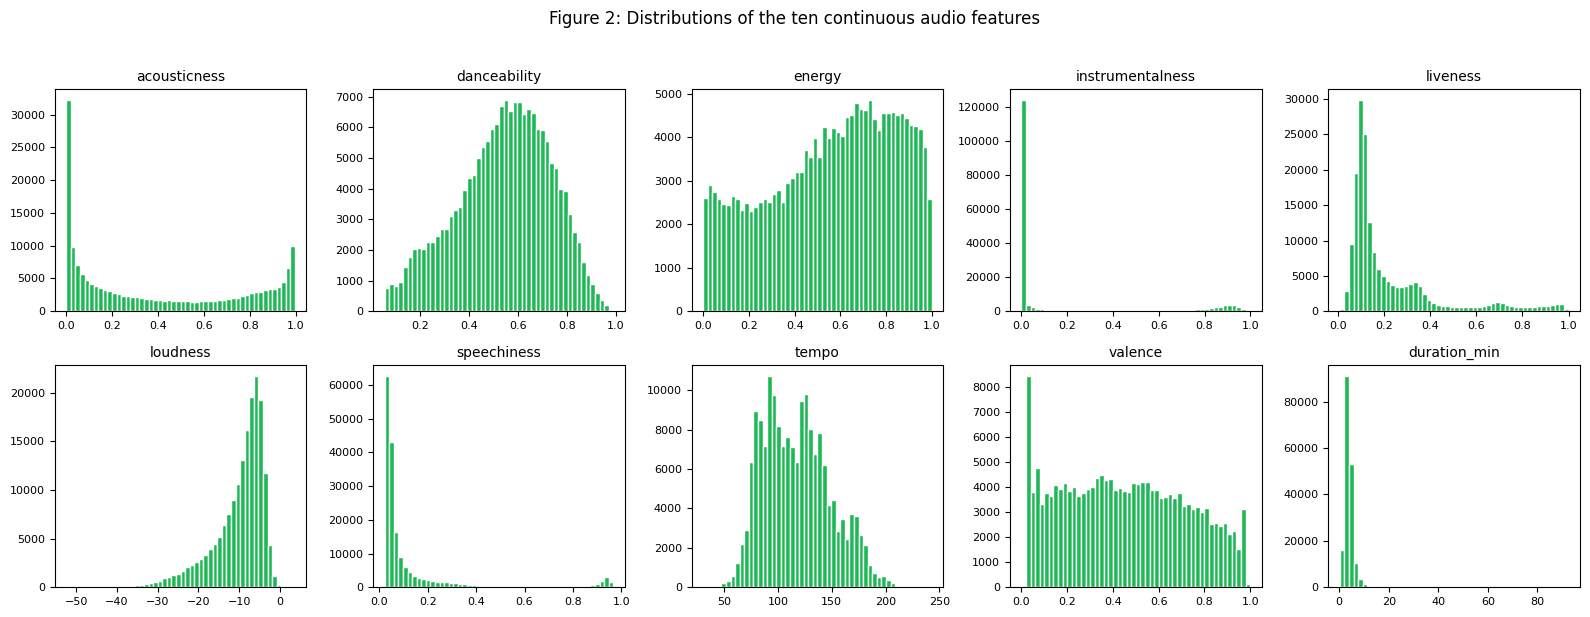

BINARY FEATURES
  mode_enc: 0 = 34.0%, 1 = 66.0%
  is_4_4: 0 = 15.6%, 1 = 84.4%

OUTLIER SUMMARY (values beyond 1.5×IQR)
feature             skew  n_outliers  % outliers
acousticness        0.37           0        0.0%
danceability       -0.33           0        0.0%
energy             -0.33           0        0.0%
instrumentalness    1.58      38,724       21.9%
liveness            1.96      17,671       10.0%
loudness           -1.48       8,621        4.9%
speechiness         3.10      25,715       14.5%
tempo               0.41         107        0.1%
valence             0.15           0        0.0%
duration_min        9.45      10,526        6.0%


In [26]:
# EDA 2.2: Feature distributions
fig, axes = plt.subplots(2, 5, figsize=(16, 6))
for ax, col in zip(axes.ravel(), continuous):
    ax.hist(df[col], bins=50, color='#1DB954', edgecolor='white')
    ax.set_title(col, fontsize=10)
    ax.tick_params(labelsize=8)
fig.suptitle('Figure 2: Distributions of the ten continuous audio features',
             y=1.02, fontsize=12)
plt.tight_layout()
plt.show()

# Binary features: quick value counts (not histograms — only two levels each)
print('BINARY FEATURES')
for col in binary:
    vc = df[col].value_counts(normalize=True).sort_index() * 100
    print(f"  {col}: 0 = {vc.get(0, 0):.1f}%, 1 = {vc.get(1, 0):.1f}%")

# Outlier summary (IQR method)
print('\nOUTLIER SUMMARY (values beyond 1.5×IQR)')
print(f"{'feature':<16}{'skew':>8}{'n_outliers':>12}{'% outliers':>12}")
for col in continuous:
    q1, q3 = df[col].quantile([0.25, 0.75])
    iqr = q3 - q1
    lo, hi = q1 - 1.5 * iqr, q3 + 1.5 * iqr
    n_out = ((df[col] < lo) | (df[col] > hi)).sum()
    print(f"{col:<16}{df[col].skew():>8.2f}{n_out:>12,}{n_out / len(df) * 100:>11.1f}%")

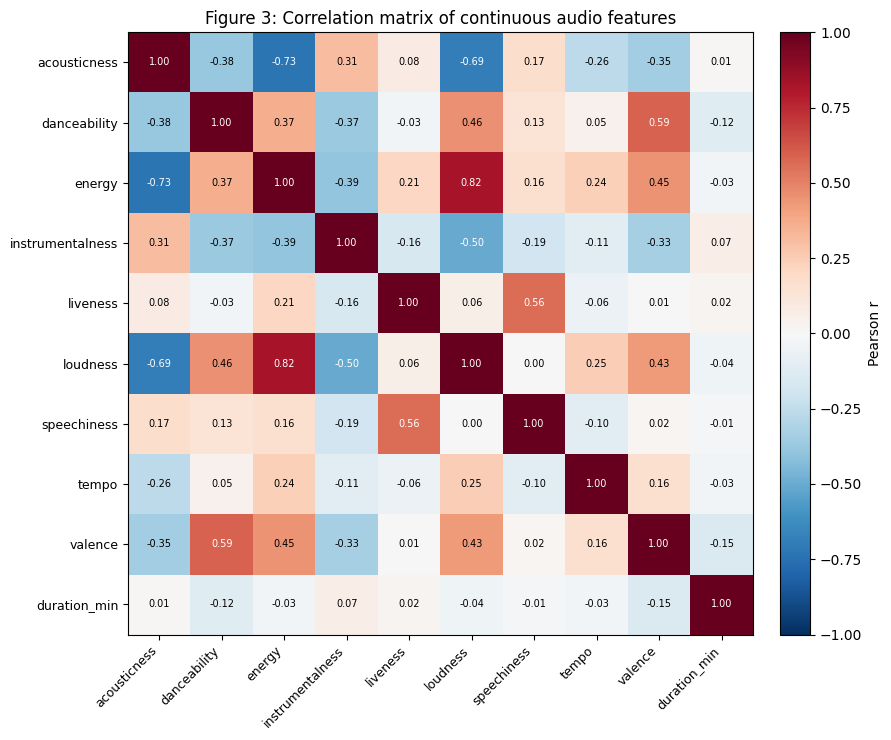

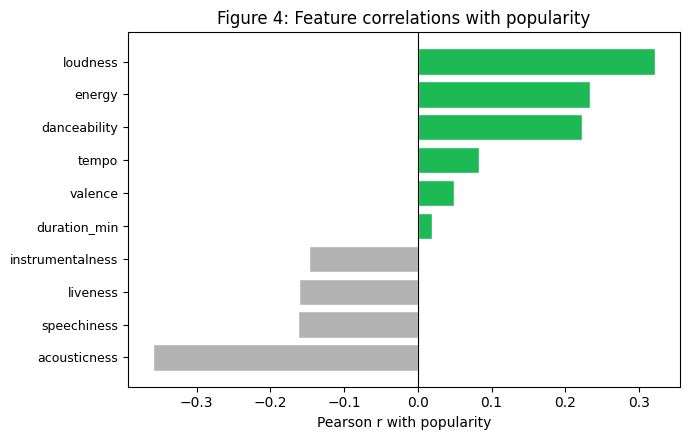

TOP FEATURE–FEATURE CORRELATIONS (|r|, excluding self)
  energy           × loudness         r = +0.825
  energy           × acousticness     r = -0.730
  loudness         × acousticness     r = -0.693
  danceability     × valence          r = +0.588
  liveness         × speechiness      r = +0.556
  instrumentalness × loudness         r = -0.501

CORRELATION WITH POPULARITY (Task 1)
loudness            0.322
energy              0.234
danceability        0.222
tempo               0.083
valence             0.049
duration_min        0.019
instrumentalness   -0.148
liveness           -0.162
speechiness        -0.162
acousticness       -0.359


In [27]:
# EDA 2.3: Correlation structure
# (a) Feature–feature heatmap (continuous features only)
feat_corr = df[continuous].corr()

fig, ax = plt.subplots(figsize=(9, 7.5))
im = ax.imshow(feat_corr, cmap='RdBu_r', vmin=-1, vmax=1, aspect='auto')
ax.set_xticks(range(len(continuous)))
ax.set_yticks(range(len(continuous)))
ax.set_xticklabels(continuous, rotation=45, ha='right', fontsize=9)
ax.set_yticklabels(continuous, fontsize=9)
for i in range(len(continuous)):
    for j in range(len(continuous)):
        val = feat_corr.iloc[i, j]
        ax.text(j, i, f'{val:.2f}', ha='center', va='center',
                fontsize=7, color='white' if abs(val) > 0.5 else 'black')
fig.colorbar(im, ax=ax, fraction=0.046, pad=0.04, label='Pearson r')
ax.set_title('Figure 3: Correlation matrix of continuous audio features', fontsize=12)
plt.tight_layout()
plt.show()

# (b) Feature–popularity correlations (Task 1 target only)
tc = df[continuous].corrwith(df['popularity']).sort_values()
fig, ax = plt.subplots(figsize=(7, 4.5))
colors = ['#B3B3B3' if v < 0 else '#1DB954' for v in tc.values]
ax.barh(range(len(tc)), tc.values, color=colors, edgecolor='white')
ax.set_yticks(range(len(tc)))
ax.set_yticklabels(tc.index, fontsize=9)
ax.axvline(0, color='black', linewidth=0.8)
ax.set_title('Figure 4: Feature correlations with popularity', fontsize=12)
ax.set_xlabel('Pearson r with popularity')
plt.tight_layout()
plt.show()

# Numeric summaries
print('TOP FEATURE–FEATURE CORRELATIONS (|r|, excluding self)')
fc = feat_corr.abs().where(~np.eye(len(continuous), dtype=bool))
pairs = fc.stack().sort_values(ascending=False).drop_duplicates().head(6)
for (a, b), v in pairs.items():
    print(f"  {a:<16} × {b:<16} r = {feat_corr.loc[a, b]:+.3f}")

print('\nCORRELATION WITH POPULARITY (Task 1)')
print(df[continuous].corrwith(df['popularity']).sort_values(ascending=False).round(3).to_string())

In [28]:
# Pivot motivation: why `mode` was rejected as the classification target
# Documented for the report's task-selection rationale. Not a modelling step.
mode_enc_tmp = (df['mode'] == 'Major').astype(int)

# Marginal correlations of features with mode
mode_corr = df[continuous].corrwith(mode_enc_tmp).abs().sort_values(ascending=False)

# Standardized class-mean separation (Cohen's d), Major vs Minor
maj, mino = df[df['mode'] == 'Major'], df[df['mode'] == 'Minor']
cohens_d = {}
for col in continuous:
    n1, n0 = len(maj), len(mino)
    pooled_sd = np.sqrt(((n1-1)*maj[col].std()**2 + (n0-1)*mino[col].std()**2) / (n1+n0-2))
    cohens_d[col] = abs(maj[col].mean() - mino[col].mean()) / pooled_sd

print("WHY WE PIVOTED FROM `mode` TO `genre`:")
print(f"  Max |feature–mode correlation|: {mode_corr.iloc[0]:.3f} ({mode_corr.index[0]})")
print(f"  Max |Cohen's d| (Major vs Minor): {max(cohens_d.values()):.3f} "
      f"({max(cohens_d, key=cohens_d.get)})")
print("  → All features near-orthogonal to mode; no model can beat the majority-class")
print("    baseline. Genre (see below) is strongly predicted by the same features.")

WHY WE PIVOTED FROM `mode` TO `genre`:
  Max |feature–mode correlation|: 0.061 (instrumentalness)
  Max |Cohen's d| (Major vs Minor): 0.130 (instrumentalness)
  → All features near-orthogonal to mode; no model can beat the majority-class
    baseline. Genre (see below) is strongly predicted by the same features.


In [29]:
# Genre viability: justify restricting to a clean 6-genre subset
raw = pd.read_csv('SpotifyFeatures.csv')

# How often does a track span multiple genres? (label-noise from dedup)
genres_per_track = raw.groupby('track_id')['genre'].nunique()
print("MULTI-GENRE DIAGNOSTIC (full dataset):")
print(f"  Tracks with exactly 1 genre: {(genres_per_track == 1).mean()*100:.1f}%")
print(f"  Tracks with >1 genre:        {(genres_per_track > 1).mean()*100:.1f}%")
print(f"  → ~20% multi-genre + 27 highly imbalanced classes (81× ratio, "
      f"tiny tail e.g. A Capella n=119)")
print(f"  → We restrict to 6 acoustically distinct, well-populated genres and")
print(f"    re-derive from raw, keeping only tracks unambiguous within the subset.\n")

SUBSET = ['Classical', 'Hip-Hop', 'Electronic', 'Jazz', 'Country', 'Comedy']

MULTI-GENRE DIAGNOSTIC (full dataset):
  Tracks with exactly 1 genre: 80.1%
  Tracks with >1 genre:        19.9%
  → ~20% multi-genre + 27 highly imbalanced classes (81× ratio, tiny tail e.g. A Capella n=119)
  → We restrict to 6 acoustically distinct, well-populated genres and
    re-derive from raw, keeping only tracks unambiguous within the subset.



In [30]:
# Build the 6-class genre subset for Task 2
SUBSET = ['Classical', 'Hip-Hop', 'Electronic', 'Jazz', 'Country', 'Comedy']

# Work from RAW (pre-dedup) so we recover tracks whose arbitrary dedup-label
# fell outside the subset.
sub = raw[raw['genre'].isin(SUBSET)].copy()
print(f"Rows in raw under the 6 subset genres: {len(sub):,}")

# Unambiguous within the subset vs spanning 2+ subset genres?
sgpt = sub.groupby('track_id')['genre'].nunique()
n_clean, n_ambig = (sgpt == 1).sum(), (sgpt > 1).sum()
print(f"Tracks in exactly 1 subset genre: {n_clean:,} ({n_clean/(n_clean+n_ambig)*100:.1f}%)")
print(f"Tracks spanning 2+ subset genres: {n_ambig:,} ({n_ambig/(n_clean+n_ambig)*100:.1f}%) -> dropped")

# Keep unambiguous tracks only, then one row per track
clean_ids = sgpt[sgpt == 1].index
gdf = (sub[sub['track_id'].isin(clean_ids)]
       .drop_duplicates(subset='track_id')
       .dropna(subset=['track_name'])
       .reset_index(drop=True))

# Feature engineering — NOTE: mode is now a PREDICTOR, not the target
gdf['mode_enc']     = (gdf['mode'] == 'Major').astype(int)
gdf['is_4_4']       = (gdf['time_signature'] == '4/4').astype(int)
gdf['duration_min'] = gdf['duration_ms'] / 60000

# Same 12-feature set as Task 1; genre is the target
print(f"\nFinal genre-subset dataset: {gdf.shape[0]:,} tracks, {len(features)} features")
vc = gdf['genre'].value_counts()
print("\nClass distribution:")
print(vc.to_string())
print(f"\nMajority-class baseline: {vc.iloc[0]/len(gdf):.4f}")
print(f"Imbalance ratio (largest/smallest): {vc.iloc[0]/vc.iloc[-1]:.2f}×")

Rows in raw under the 6 subset genres: 55,714
Tracks in exactly 1 subset genre: 54,070 (98.5%)
Tracks spanning 2+ subset genres: 821 (1.5%) -> dropped

Final genre-subset dataset: 54,070 tracks, 12 features

Class distribution:
genre
Comedy        9680
Classical     9194
Hip-Hop       9180
Electronic    8755
Jazz          8658
Country       8603

Majority-class baseline: 0.1790
Imbalance ratio (largest/smallest): 1.13×


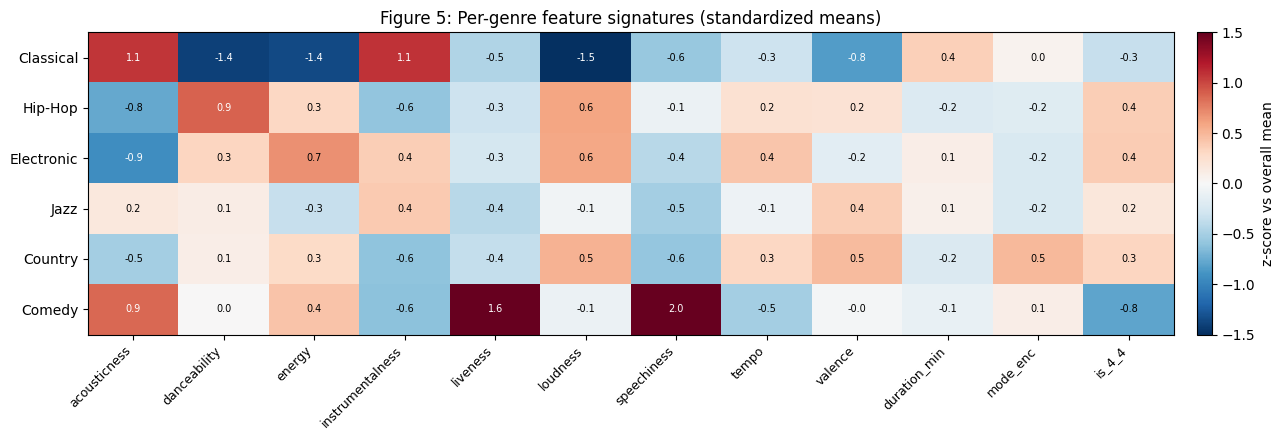

FEATURE DISCRIMINATIVE POWER (η² = fraction of variance explained by genre)
  speechiness      0.862
  acousticness     0.615
  liveness         0.594
  loudness         0.545
  danceability     0.486
  energy           0.470
  instrumentalness 0.433
  is_4_4           0.202
  valence          0.187
  tempo            0.115
  mode_enc         0.062
  duration_min     0.041

COVARIANCE DIVERGENCE FROM POOLED (per genre, relative Frobenius):
  Classical    0.155
  Hip-Hop      0.055
  Electronic   0.182
  Jazz         0.022
  Country      0.079
  Comedy       0.092

5-FOLD CV ACCURACY (majority-class baseline = 0.179)
  LDA: 0.7431 ± 0.0085
  QDA: 0.7332 ± 0.0046


In [31]:
from sklearn.model_selection import cross_val_score

X_g = gdf[features]
y_g = gdf['genre']

# (a) Per-genre feature signature: z-scored mean of each feature per genre
z = (X_g - X_g.mean()) / X_g.std()
sig = z.groupby(gdf['genre']).mean().loc[SUBSET]   # genres × features, in SUBSET order

fig, ax = plt.subplots(figsize=(13, 4.5))
im = ax.imshow(sig.values, cmap='RdBu_r', vmin=-1.5, vmax=1.5, aspect='auto')
ax.set_xticks(range(len(features))); ax.set_xticklabels(features, rotation=45, ha='right', fontsize=9)
ax.set_yticks(range(len(SUBSET)));   ax.set_yticklabels(SUBSET, fontsize=10)
for i in range(len(SUBSET)):
    for j in range(len(features)):
        v = sig.values[i, j]
        ax.text(j, i, f'{v:.1f}', ha='center', va='center', fontsize=7,
                color='white' if abs(v) > 0.8 else 'black')
fig.colorbar(im, ax=ax, fraction=0.025, pad=0.02, label='z-score vs overall mean')
ax.set_title('Figure 5: Per-genre feature signatures (standardized means)', fontsize=12)
plt.tight_layout(); plt.show()

# (b) Which features discriminate genre? (ANOVA n² = variance explained)
def eta_sq(col):
    grand = X_g[col].mean()
    ss_tot = ((X_g[col] - grand) ** 2).sum()
    ss_bet = sum((y_g == g).sum() * (X_g[col][y_g == g].mean() - grand) ** 2 for g in SUBSET)
    return ss_bet / ss_tot

print("FEATURE DISCRIMINATIVE POWER (η² = fraction of variance explained by genre)")
etas = sorted(((col, eta_sq(col)) for col in features), key=lambda x: -x[1])
for col, e in etas:
    print(f"  {col:<16} {e:.3f}")

# (c) Covariance-structure diagnostic (LDA assumes classes share covariance)
covs = {g: X_g[continuous][y_g == g].cov().values for g in SUBSET}
n = {g: (y_g == g).sum() for g in SUBSET}
pooled = sum((n[g] - 1) * covs[g] for g in SUBSET) / (len(gdf) - len(SUBSET))
print("\nCOVARIANCE DIVERGENCE FROM POOLED (per genre, relative Frobenius):")
for g in SUBSET:
    rel = np.linalg.norm(covs[g] - pooled) / np.linalg.norm(pooled)
    print(f"  {g:<12} {rel:.3f}")

# (d) Head-to-head: LDA vs QDA in 5-fold CV (settles the discriminant choice)
lda_pipe = make_pipeline(StandardScaler(), LinearDiscriminantAnalysis())
qda_pipe = make_pipeline(StandardScaler(), QuadraticDiscriminantAnalysis())
lda_cv = cross_val_score(lda_pipe, X_g, y_g, cv=5, scoring='accuracy')
qda_cv = cross_val_score(qda_pipe, X_g, y_g, cv=5, scoring='accuracy')
maj_baseline = y_g.value_counts(normalize=True).max()
print(f"\n5-FOLD CV ACCURACY (majority-class baseline = {maj_baseline:.3f})")
print(f"  LDA: {lda_cv.mean():.4f} ± {lda_cv.std():.4f}")
print(f"  QDA: {qda_cv.mean():.4f} ± {qda_cv.std():.4f}")

## 3–4. Task 1: Regression — Predicting Popularity


*   Setup: split, baseline, extra imports
*   Linear models: OLS, Ridge, Lasso (α selected by 5-fold CV)
*   Random Forest: non-linear comparison
*   Model comparison
*   Explainability: standardized OLS coefficients vs RF importances



In [32]:
# Task 1 setup: split, baseline, extra imports
from sklearn.model_selection import GridSearchCV
from sklearn.ensemble import RandomForestRegressor
from sklearn.metrics import mean_squared_error, r2_score

X = df[features]        # 12 predictors
y = df['popularity']    # regression target (full dataset)

X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED)

# Baseline: predict the training mean for every track
baseline_pred = np.full(len(y_test), y_train.mean())
baseline_rmse = np.sqrt(mean_squared_error(y_test, baseline_pred))
print(f"Train / test sizes: {len(X_train):,} / {len(X_test):,}")
print(f"Baseline (predict mean) — test RMSE: {baseline_rmse:.3f}, test R²: {r2_score(y_test, baseline_pred):.3f}")

Train / test sizes: 141,418 / 35,355
Baseline (predict mean) — test RMSE: 17.415, test R²: -0.000


In [33]:
# Linear models: OLS, Ridge, Lasso (α selected by 5-fold CV)
results = []

def evaluate(name, model, hyperparam=""):
    """Fit on train; record train/test RMSE and R²; store for the comparison table."""
    model.fit(X_train, y_train)
    tr, te = model.predict(X_train), model.predict(X_test)
    results.append({
        'Model': name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, tr)),
        'Test RMSE':  np.sqrt(mean_squared_error(y_test, te)),
        'Train R²':   r2_score(y_train, tr),
        'Test R²':    r2_score(y_test, te),
        'Hyperparam': hyperparam,
    })
    return model

# OLS (no tuning)
ols = evaluate("OLS", make_pipeline(StandardScaler(), LinearRegression()))

# Ridge — tune alpha over a grid
ridge_grid = GridSearchCV(
    make_pipeline(StandardScaler(), Ridge()),
    {'ridge__alpha': [0.1, 1, 10, 50, 100, 200, 500]},
    cv=5, scoring='neg_mean_squared_error')
ridge_grid.fit(X_train, y_train)
a_ridge = ridge_grid.best_params_['ridge__alpha']
evaluate("Ridge", make_pipeline(StandardScaler(), Ridge(alpha=a_ridge)), f"alpha = {a_ridge}")

# Lasso — tune alpha over a grid
lasso_grid = GridSearchCV(
    make_pipeline(StandardScaler(), Lasso(max_iter=5000)),
    {'lasso__alpha': [0.001, 0.01, 0.1, 1]},
    cv=5, scoring='neg_mean_squared_error')
lasso_grid.fit(X_train, y_train)
a_lasso = lasso_grid.best_params_['lasso__alpha']
evaluate("Lasso", make_pipeline(StandardScaler(), Lasso(alpha=a_lasso, max_iter=5000)), f"alpha = {a_lasso}")

print(f"Best Ridge alpha: {a_ridge}   |   Best Lasso alpha: {a_lasso}")

Best Ridge alpha: 50   |   Best Lasso alpha: 0.001


In [ ]:
# Task 1: tree models — fixed sensible hyperparameters (fast, robust)
try:
    from xgboost import XGBRegressor
except ImportError:
    import subprocess, sys
    subprocess.run([sys.executable, "-m", "pip", "install", "xgboost", "-q"])
    from xgboost import XGBRegressor

results = [r for r in results if r['Model'] in ('OLS', 'Ridge', 'Lasso')]  # keep linear rows

def record(name, model, hyperparam=""):
    tr, te = model.predict(X_train), model.predict(X_test)
    results.append({
        'Model': name,
        'Train RMSE': np.sqrt(mean_squared_error(y_train, tr)),
        'Test RMSE':  np.sqrt(mean_squared_error(y_test, te)),
        'Train R²':   r2_score(y_train, tr),
        'Test R²':    r2_score(y_test, te),
        'Hyperparam': hyperparam,
    })

# Random Forest — min_leaf=30 curbs overfitting
rf = RandomForestRegressor(
    n_estimators=200, max_depth=20, min_samples_leaf=30,
    n_jobs=-1, random_state=SEED)
rf.fit(X_train, y_train)
record("Random Forest", rf, "max_depth=20, min_leaf=30, n_est=200")
print("RF done.")

# XGBoost — standard solid defaults
xgb = XGBRegressor(
    n_estimators=400, max_depth=6, learning_rate=0.1,
    n_jobs=-1, random_state=SEED, verbosity=0)
xgb.fit(X_train, y_train)
record("XGBoost", xgb, "max_depth=6, lr=0.1, n_est=400")
print("XGBoost done.")

res_df = pd.DataFrame(results).set_index('Model').round(3)
print(f"\nBaseline test RMSE = {baseline_rmse:.3f}\n")
print(res_df.to_string())

In [ ]:
# Task 1 model comparison
res_df = pd.DataFrame(results).set_index('Model').round(3)
print(f"Baseline test RMSE = {baseline_rmse:.3f}  (mean-prediction reference)\n")
print(res_df.to_string())

In [ ]:
# Explainability: standardized OLS coefficients vs RF importances
ols_coefs = pd.Series(ols.named_steps['linearregression'].coef_, index=features).sort_values()
xgb_imp    = pd.Series(rf.feature_importances_, index=features).sort_values()

fig, axes = plt.subplots(1, 2, figsize=(14, 5))
cols = ['#B3B3B3' if v < 0 else '#1DB954' for v in ols_coefs.values]
axes[0].barh(range(len(ols_coefs)), ols_coefs.values, color=cols, edgecolor='white')
axes[0].set_yticks(range(len(ols_coefs))); axes[0].set_yticklabels(ols_coefs.index, fontsize=9)
axes[0].axvline(0, color='black', lw=0.8)
axes[0].set_title('OLS standardized coefficients')
axes[0].set_xlabel('Popularity points per 1 SD of feature')

axes[1].barh(range(len(xgb_imp)), xgb_imp.values, color='#1DB954', edgecolor='white')
axes[1].set_yticks(range(len(xgb_imp))); axes[1].set_yticklabels(xgb_imp.index, fontsize=9)
axes[1].set_title('Random Forest feature importances')
axes[1].set_xlabel('Importance')

fig.suptitle('Figure 6: Feature importance for popularity (OLS coefficients vs Random Forest)',
             y=1.02, fontsize=12)
plt.tight_layout(); plt.show()

print("OLS STANDARDIzED COEFFICIENTS (sorted):")
print(ols_coefs.round(3).to_string())
print(f"\n→ Valence coefficient (sign check): {ols_coefs['valence']:+.3f}")

## 3–4. Task 2: Classification — Predicting Genre

In [ ]:
# Task 2 setup: split, baseline
from sklearn.ensemble import RandomForestClassifier
from sklearn.metrics import precision_recall_fscore_support, classification_report

X_g = gdf[features]
y_g = gdf['genre']

Xg_train, Xg_test, yg_train, yg_test = train_test_split(
    X_g, y_g, test_size=0.2, random_state=SEED, stratify=y_g)   # stratify keeps class balance

maj_baseline = yg_train.value_counts(normalize=True).max()
print(f"Train / test sizes: {len(Xg_train):,} / {len(Xg_test):,}")
print(f"Majority-class baseline accuracy: {maj_baseline:.3f}")
print(f"Classes ({len(SUBSET)}): {SUBSET}")

In [ ]:
# Task 2: fit four classifiers, collect macro metrics
clf_results, fitted = [], {}

def eval_clf(name, model, hyperparam=""):
    model.fit(Xg_train, yg_train)
    pred = model.predict(Xg_test)
    prec, rec, f1, _ = precision_recall_fscore_support(
        yg_test, pred, average='macro', zero_division=0)
    clf_results.append({
        'Model': name,
        'Accuracy': accuracy_score(yg_test, pred),
        'Macro P': prec, 'Macro R': rec, 'Macro F1': f1,
        'Hyperparam': hyperparam,
    })
    fitted[name] = model
    return model

# Multinomial logistic regression — tune C by 3-fold CV (lbfgs does multinomial)
logit_grid = GridSearchCV(
    make_pipeline(StandardScaler(), LogisticRegression(max_iter=1000)),
    {'logisticregression__C': [0.1, 1, 10]},
    cv=3, scoring='accuracy', n_jobs=-1)
logit_grid.fit(Xg_train, yg_train)
best_C = logit_grid.best_params_['logisticregression__C']
eval_clf("Logistic Regression",
         make_pipeline(StandardScaler(), LogisticRegression(C=best_C, max_iter=1000)),
         f"C = {best_C}")

# LDA (primary) and QDA — standardized pipelines
eval_clf("LDA", make_pipeline(StandardScaler(), LinearDiscriminantAnalysis()))
eval_clf("QDA", make_pipeline(StandardScaler(), QuadraticDiscriminantAnalysis()))

# Random Forest — fixed sensible hyperparameters
eval_clf("Random Forest",
         RandomForestClassifier(n_estimators=200, max_depth=20,
                                min_samples_leaf=5, n_jobs=-1, random_state=SEED),
         "depth=20, min_leaf=5, n_est=200")

print(f"Best logistic C: {best_C}")

In [ ]:
# Task 2 model comparison
clf_df = pd.DataFrame(clf_results).set_index('Model').round(3)
print(f"Majority-class baseline accuracy = {maj_baseline:.3f}\n")
print(clf_df.to_string())

In [ ]:
# Confusion matrix for the best model
best_name = clf_df['Accuracy'].idxmax()
best_model = fitted[best_name]
pred_best = best_model.predict(Xg_test)
print(f"Best model: {best_name} (test accuracy {clf_df.loc[best_name, 'Accuracy']:.3f})\n")

fig, ax = plt.subplots(figsize=(7, 6))
cm = confusion_matrix(yg_test, pred_best, labels=SUBSET, normalize='true')
ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=SUBSET).plot(
    ax=ax, cmap='Greens', values_format='.2f', colorbar=False)
ax.set_title(f'Figure 7: Confusion matrix — {best_name} (row-normalized)')
plt.xticks(rotation=45, ha='right')
plt.tight_layout()
plt.show()

print("Per-class report:")
print(classification_report(yg_test, pred_best, digits=3))